In [182]:
import numpy as np
import os
import shutil
import random
import scipy.io
from scipy.optimize import lsq_linear
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp2d
from scipy.stats import norm
import matplotlib.mlab as mlab

import requests
from astropy.time import Time
from astropy import units as u
from sunpy.coordinates import get_horizons_coord
from astropy.coordinates import SkyCoord, CartesianRepresentation, get_sun


In [243]:
famid = '4' ## family to explore
cat = 'allsky_4band_p1bs_psd'  ## catalog used to generate the input .obs files
filterpriority = 'w3'  ## filter of photometry to be analyzed
diam_low = 3.   ## lower diameter limit of sample (in km) as recorded in the neowise catalog file.
diam_high = 5.  ## upper diameter limit of sample (in km) as recorded in the neowise catalog file.

phase_angle_limit = 40 ## upper limit to solar phase angle tolerated.  30 came standard with LEADER
Ndraws = 1000 ## number of times to randomly draw from the input object photometry files to assess physical properties
Ntrials = 100  ## number of times to evaluate the p and beta distributions from Ndraws (i.e., number of times to repeat this experiment)
overwrite = False
convert2degrees = True
neowise_fle = 'neowise_mainbelt.csv' ## name of the asteroid catalog file containing names and NEOWISE-determined properties, from the PDS SBN

date_tol = 60  ## maximum allowed difference between JD of neighboring data points
wanted = 11     ## minimum number of data points per object per epoch


In [244]:
def lcg_read_WISE(fname):
       
    fid = open(fname, 'r')

    lines = [line.rstrip() for line in fid] # All lines including the blank ones

    nblocks = int(lines[0])

    dates = np.zeros(nblocks)
    e_sun = np.zeros((nblocks, 3))
    e_earth = np.zeros((nblocks, 3))
    flux = [[None for _ in range(4)] for _ in range(nblocks)]
    fluxerr = [[None for _ in range(4)] for _ in range(nblocks)]

    ilinestart = 1
    for i in range(nblocks):

        if lines[ilinestart]:
            dates[i] = float(lines[ilinestart].split()[0])
            nfilters = int(lines[ilinestart].split()[1])
            e_sun[i,:] = lines[ilinestart+1].split()
            e_earth[i,:] = lines[ilinestart+2].split()
            for j in range(nfilters):
                filter_index = int(lines[ilinestart+3+j].split()[3])
                flux[i][filter_index] = float(lines[ilinestart+3+j].split()[1])
                fluxerr[i][filter_index] = float(lines[ilinestart+3+j].split()[2])
            ilinestart += 5 + nfilters

        else:
            ilinestart += 1

        # Construct vectors from flux and flux error
        flux1, flux2, flux3, flux4 = [], [], [], []
        flux1e, flux2e, flux3e, flux4e = [], [], [], []

    for i in range(nblocks):
        if flux[i][0] is not None:
            flux1.append(flux[i][0])
            flux1e.append(fluxerr[i][0])

        if flux[i][1] is not None:
            flux2.append(flux[i][1])
            flux2e.append(fluxerr[i][1])

        if flux[i][2] is not None:
            flux3.append(flux[i][2])
            flux3e.append(fluxerr[i][2])

        if flux[i][3] is not None:
            flux4.append(flux[i][3])
            flux4e.append(fluxerr[i][3])

    # Compute total errors
    flux_tot_err = [
        np.linalg.norm(flux1e) if flux1e else 0,
        np.linalg.norm(flux2e) if flux2e else 0,
        np.linalg.norm(flux3e) if flux3e else 0,
        np.linalg.norm(flux4e) if flux4e else 0,
    ]

    # Discard empty filters
    flux_tot_err = [err if err != 0 else np.inf for err in flux_tot_err]

    # Best filter (index from 0 to 3)
    bestf = flux_tot_err.index(min(flux_tot_err))

    # Collect intensity data from best filter
    L_big = np.asarray([flux[i][bestf] for i in range(nblocks) if flux[i][bestf] is not None])
    indeksit = np.asarray([i for i in range(nblocks) if flux[i][bestf] is not None])

    # Filter corresponding entries
    e_sun = e_sun[indeksit, :]
    e_earth = e_earth[indeksit, :]
    dates = dates[indeksit]

    # Normalize vectors (equivalent to MATLAB's normr)
    def normr(mat):
        norms = np.linalg.norm(mat, axis=1, keepdims=True)
        norms[norms == 0] = 1  # Prevent division by zero
        return mat / norms


    e_sun = normr(e_sun)
    e_earth = normr(e_earth)

    # Remove measurements with phase angle > ang_tol
    ang_tol = np.deg2rad(phase_angle_limit)
    largeanglepoints = np.zeros(len(L_big), dtype=bool)
    ang = np.zeros(len(L_big))

    for i in range(len(L_big)):
        ang[i] = np.arccos(np.clip(np.dot(e_sun[i,:], e_earth[i,:]), -1.0, 1.0))
        if ang[i] > ang_tol:
            largeanglepoints[i] = True

    # Filter out removed measurements
    dates = dates[~largeanglepoints]
    L_big = L_big[~largeanglepoints]
    e_sun = e_sun[~largeanglepoints]
    e_earth = e_earth[~largeanglepoints]
    ang = ang[~largeanglepoints]

    A = []
    i = 0

    # Backup storage
    dates_back = []
    ang_back = []
    temp_angle = []
    L_back = []
    pointsperapp = []
    Nappar = 0      ## number of apparitions (epochs)

    while i < len(L_big)-1:
        L = [L_big[i]]

        for j in range(i + 1, len(L_big)):
            if dates[j] - dates[i] <= date_tol:
                L.append(L_big[j])
                if j == len(L_big) - 1:
                    i_old = i
                    i = j
            else:
                i_old = i
                i = j
                break

        # Store data for this apparition
        dates_back.extend(dates[i_old:i_old + len(L)])
        ang_back.extend(ang[i_old:i_old + len(L)])
        L_back.extend(L)
        pointsperapp.append(len(L))
        Nappar += 1

        temp = ang[i_old:i_old + len(L)]
        temp_angle.append(np.max(temp) - np.min(temp))


    Nappar_eff = Nappar
    date_tol_appar = date_tol

    if 'dates_back' in locals() and len(dates_back) > 0:
        dates_back = dates_back - dates_back[0]
        ang_back = np.rad2deg(ang_back)

    if len(L_back) > 0:
        Nappar,L_back = leader_phasecorr(Nappar,pointsperapp,dates,ang_back,L_back)    

    A = []
    Npoints = []

    # Compute eta for each set
    for i in range(Nappar_eff):
        ind = int(np.sum(pointsperapp[:i]))
        inde = int(ind + pointsperapp[i] - 1)

        if Nappar > Nappar_eff:
            # The case of combined sets
            L = L_back
        else:
            L = L_back[ind:inde]

        # If we have over 'wanted' data points, compute eta and A
        if len(L) >= wanted:
            isample = list(np.arange(len(L)))
            iselect = random.sample(isample,wanted)    
            L = np.asarray(L)[iselect]
            
            Npoints.append(np.mean(len(L)))
            L2 = np.asarray(L)**2.
            eta = np.std(L2) / np.mean(L2)
            A_val = np.sqrt(1 - 1 / ((1 / (np.sqrt(8) * eta)) + 0.5))
            A.append(A_val)

    A = np.array(A)
    Npoints = np.asarray(Npoints)
    
    if len(Npoints) > 0:
        Npoints_avg = np.mean(np.asarray(Npoints))
    else:
        Npoints_avg = 0

    # Remove complex and non-finite amplitudes
    A = A[np.isreal(A)]
    A = A[np.isfinite(A)]

        
    return (Npoints_avg,Nappar,A)



In [245]:
def leader_phasecorr(Nappar,pointsperapp,dates,ang_back,L_back):

    # Phase correction if phase angle changes too much
    crit_change1 = 1
    crit_change2 = 2
    crit_low = 8

    for i in range(Nappar):
        ind = int(np.sum(pointsperapp[:i]))
        inde = int(ind + pointsperapp[i]-1)
        temp = ang_back[ind:inde]

        # Determine whether exponential or linear correction is needed
        if len(temp) > 1:
            expcorr = (np.min(temp) < crit_low) and (np.max(temp) - np.min(temp) > crit_change1)
            lincorr = (np.min(temp) >= crit_low) and (np.max(temp) - np.min(temp) > crit_change2)

            if expcorr is True:
                # Phase correction with exponential fit
                AA = np.vstack([np.ones_like(temp), temp]).T
                yy = np.log(L_back[ind:inde])
                xx, _, _, _ = np.linalg.lstsq(AA, yy, rcond=None)

                if xx[1] > 0:
                    XX0 = 1.0
                    XX1 = 0.0
                else:
                    XX0 = np.exp(xx[0])
                    XX1 = xx[1]

                L_back[ind:inde] = L_back[ind:inde] / (XX0 * np.exp(XX1 * temp))

            elif lincorr is True:
                # Phase correction with linear fit
                AA = np.vstack([temp, np.ones_like(temp)]).T
                yy = L_back[ind:inde]
                xx, _, _, _ = np.linalg.lstsq(AA, yy, rcond=None)

                if xx[0] > 0 or xx[1] < 0:
                    XX = [0.0, 1.0]
                else:
                    XX = xx

                L_back[ind:inde] = L_back[ind:inde] / (XX[0] * temp + XX[1])

    # Determine if all measurements are from a single apparition
    single_apparition = False
    if 'dates' in locals() and len(dates) > 0:
        single_apparition = (dates[-1] - dates[0]) <= date_tol


    # Combine sets into a single apparition if needed
    if (Nappar > 1 and np.any(np.asarray(pointsperapp) < wanted) and single_apparition):
        # Set the scaling according to the first set
        avg_scale = np.mean(L_back[:pointsperapp[0]])

        for i in range(1, Nappar):
            ind = int(np.sum(pointsperapp[:i]))
            inde = int(ind + pointsperapp[i] - 1)
            avg_temp = np.mean(L_back[ind:inde])
            scale_factor = avg_scale / avg_temp
            L_back[ind:inde] = scale_factor * L_back[ind:inde]

        Nappar_eff = 1
    
    return (single_apparition, L_back)




In [246]:
def leader_invert(Asort):

    # Number of bins
    NP = 20
    NBETA = 29

    # Bin ranges
    P = np.linspace(0.025, 0.975, NP)
    BETA = np.linspace(0.025, 1.55, NBETA)

    # Optional grid type logic
    if 'gridtype' in locals() and gridtype == 'dynamic':
        temp = np.zeros(2)
        temp[0] = P[np.random.randint(0, 5)]      # p < 0.25
        temp[1] = P[np.random.randint(5, 8)]      # 0.25 < p < 0.4
        temp = np.concatenate([temp, P[8:]])      # Rest as-is
        P = temp

    # Perturb bins with truncated Gaussian noise
    coeff = 0.015

    def truncated_gaussian_noise(arr, max_val=0.025):
        noise = coeff * np.random.randn(len(arr))
        for i in range(len(noise)):
            while abs(noise[i]) > max_val:
                noise[i] = coeff * np.random.randn()
        return noise

    P += truncated_gaussian_noise(P)

    if 'gridtype' in locals() and gridtype == 'dynamic':
        temp = np.zeros(5)
        temp[0] = BETA[np.random.randint(0, 6)]      # 0–18.5°
        temp[1] = BETA[np.random.randint(6, 8)]      # 18.5–24.7°
        temp[2] = BETA[np.random.randint(8, 10)]     # 24.7–31°
        temp[3] = BETA[np.random.randint(10, 12)]    # 31–37.2°
        temp[4] = BETA[np.random.randint(12, 14)]    # 37.2–43.4°
        temp = np.concatenate([temp, BETA[14:]])     # Rest as-is
        BETA = temp

    BETA = np.minimum(BETA + truncated_gaussian_noise(BETA), np.pi / 2 - np.finfo(float).eps)
    
    # Build matrix M for the linear system M*w = C
    M = np.zeros((len(Asort), len(P) * len(BETA)))
    ind = 0
    for j in range(len(P)):
        for k in range(len(BETA)):
            for i in range(len(Asort)):
                A_val = Asort[i]
                beta_val = BETA[k]
                p_val = P[j]
                if A_val <= p_val:
                    M[i, ind] = 0
                elif A_val < np.sqrt(np.sin(beta_val) ** 2 + p_val ** 2 * np.cos(beta_val) ** 2):
                    val = np.sqrt((A_val ** 2 - p_val ** 2) / (1 - p_val ** 2))
                    M[i, ind] = np.pi / 2 - np.arccos(val / np.sin(beta_val))
                else:
                    M[i, ind] = np.pi / 2
            ind += 1

    # Regularization matrices RP and RB
    NN = len(P)
    MM = len(BETA)
    RP = np.zeros(((NN - 1) * MM, NN * MM))
    RB = np.zeros((NN * (MM - 1), NN * MM))

    for k in range(RP.shape[0]):
        pindex = math.ceil((k + 1) / MM) - 1  # Convert 1-based MATLAB index to 0-based
        RP[k, k] = -1 / (P[pindex + 1] - P[pindex])
        RP[k, k + MM] = 1 / (P[pindex + 1] - P[pindex])

    for k in range(RB.shape[0]):
        ll = k + math.ceil((k + 1) / (MM - 1)) - 1
        bindex = k % (MM - 1)
        if bindex == 0 and (k + 1) % (MM - 1) == 0:
            bindex = MM - 1
        RB[k, ll] = -1 / (BETA[bindex + 1] - BETA[bindex])
        RB[k, ll + 1] = 1 / (BETA[bindex + 1] - BETA[bindex])

    # Regularization parameters
    deltaP = deltaP if 'deltaP' in locals() and deltaP is not None else 0.1
    deltaB = deltaB if 'deltaB' in locals() and deltaB is not None else 1

    # Extended system
    Mtilde = np.vstack([M, np.sqrt(deltaP) * RP, np.sqrt(deltaB) * RB])
    Mtilde = np.nan_to_num(Mtilde, nan=0.0)
    Ctilde = np.concatenate([CDFA, np.zeros(RP.shape[0]), np.zeros(RB.shape[0])])
    Ctilde = np.nan_to_num(Ctilde, nan=0.0)     
    
    # Solve Mtilde * w = Ctilde with positivity constraint
    print("Solving the weights w_ij for the bins (p_i, beta_j)...")
    result = lsq_linear(Mtilde, Ctilde, bounds=(0, np.inf), method='trf', lsmr_tol='auto', verbose=0)
    W = result.x
    print("Solution obtained!")
    
    # Reshape solution vector into matrix
    W_back = W.copy()
    W = W.reshape((len(P), len(BETA)))

    # Find the peak
    max_idx = np.unravel_index(np.argmax(W), W.shape)
    pmax = P[max_idx[0]]
    betamax = BETA[max_idx[1]]

    P_Gr, BETA_Gr = np.meshgrid(P, BETA, indexing='ij')

    # Relative error
    relerr = np.linalg.norm(M @ W_back - CDFA) / np.linalg.norm(CDFA)

    # Output
    print(f"The highest peak: P = {pmax}, BETA = {betamax}")
    print(f"Relative error: {relerr}")
    
    return (pmax,betamax,relerr,M,W_back,W,P,BETA,P_Gr,BETA_Gr)



In [247]:
def leader_plots():

    # --- 1. Plot CDF(A) and the function approximation ---
    plt.figure()
    plt.plot(Asort, CDFA, 'bo', label='CDF of A')
    plt.plot(Asort, M @ W_back, 'rx', label=r'$\sum w_{ij} F_{ij}$')
    plt.grid(True)
    plt.xlabel('A')
    plt.title(f'Relative error of the fit: {relerr:.5f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(outdir+'/Trial'+str(trial+1)+'/RelativeError_trial'+str(trial+1)+'.png',dpi=300)
    plt.show()
    plt.close()

    # --- 2. Surface plot of weights W (occupation numbers) ---
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    P_grid, BETA_grid = np.meshgrid(P, BETA, indexing='ij')
    
    ax.plot_surface(P_grid, BETA_grid, W, cmap='viridis', edgecolor='none')

    # Highlight the peak
    ax.plot([pmax], [betamax], [np.max(W)], 'rx', markersize=10, label='Peak')

    # Optional: highlight known (p, beta) if defined
    if 'p' in locals() and 'beta' in locals() and len(np.atleast_1d(p)) == 1 and len(np.atleast_1d(beta)) == 1:
        interp_func = interp2d(BETA, P, W, kind='linear')  # W needs to be [P x BETA] shape
        w_interp = interp_func(beta, p)
        ax.plot([p], [beta], [w_interp[0]], 'mx', markersize=10, label='True peak')

    ax.set_xlim(0, 1)
    if convert2degrees is True:
        ax.set_ylim(0,90)
        ax.set_ylabel(r'$\beta$'+' (deg)')
    else:
        ax.set_ylim(0, np.pi / 2)
        ax.set_ylabel(r'$\beta$')
    ax.set_xlabel('p')
    ax.set_zlabel('w')
    ax.set_title('Occupation numbers (w)')
    plt.tight_layout()
    plt.savefig(outdir+'/Trial'+str(trial+1)+'/OccupationNumbers_w_trial'+str(trial+1)+'.png',dpi=300)
    plt.show()
    plt.close()

    # --- 3. Contour plot ---
    plt.figure()
    cp = plt.contourf(P, BETA, W.T, levels=100, cmap='viridis')  # W.T = shape [BETA x P]
    plt.colorbar(cp)
    plt.xlabel('p')
    plt.ylabel(r'$\beta$')
    plt.title('Contour plot of occupation weights')
    plt.tight_layout()
    plt.savefig(outdir+'/Trial'+str(trial+1)+'/OccupationNumbers_w_contour_trial'+str(trial+1)+'.png',dpi=300)
    plt.show()
    plt.close()

    # --- 4. Marginal distributions ---
    if 'marginplots' not in locals() or marginplots is None:
        marginplots = False

    Pmargin = np.sum(W, axis=1)   # Sum over beta (rows)
    Bmargin = np.sum(W, axis=0)   # Sum over p (columns)

    # Marginal over p
    plt.figure()
    plt.bar(P, Pmargin, width=0.04)
    plt.xlabel('p')
    plt.ylabel('w')
    plt.ylim(0, max(np.max(Pmargin), 0.2))
    plt.title('Marginal DF of p')
    plt.tight_layout()
    plt.savefig(outdir+'/Trial'+str(trial+1)+'/Margin_p_trial'+str(trial+1)+'.png',dpi=300)
    plt.show()
    plt.close()

    # Marginal over beta
    plt.figure()
    if convert2degrees is True:
        plt.bar(BETA, Bmargin, width=4.)
        plt.ylim(0, max(np.max(Bmargin), 0.2))
    else:
        plt.bar(BETA, Bmargin, width=0.05)
        plt.ylim(0, max(np.max(Bmargin), 0.2))
    plt.xlabel(r'$\beta$')
    plt.ylabel('w')
    plt.title('Marginal DF of β')
    plt.tight_layout()
    plt.savefig(outdir+'/Trial'+str(trial+1)+'/Margin_beta_trial'+str(trial+1)+'.png',dpi=300)
    plt.show()
    plt.close()
    
    # --- 5. Diameter distribution of the population used ---
    
    diam_used = np.genfromtxt(outdir+'/Trial'+str(trial+1)+'/ObjectsDrawn_famid'+str(famid)+'trial'+str(trial+1)+'.txt',unpack=True,usecols=(2),dtype=float,skip_header=1)
    diam_used = np.asarray(diam_used)
    binsize = int(Ndraws/20.)
    plt.hist(diam_used,binsize)
    plt.xlabel('Diameter (km)')
    plt.ylabel('Number of times this diameter '+'\n'+'was drawn from the sample')
    plt.title('Sample used for Trial '+str(trial+1))
    plt.tight_layout()
    plt.savefig(outdir+'/Trial'+str(trial+1)+'/ObjectsDrawn_famid'+str(famid)+'trial'+str(trial+1)+'.png',dpi=300)
    plt.show()
    plt.close()
    
    outfile = open(outdir+'/Trial'+str(trial+1)+'/MarginalDF_p_beta_trial'+str(trial+1)+'.txt','w+')
    outfile.write('p   DF_p   Beta   DF_beta\n')
    for i in range(len(Pmargin)):
        outfile.write("%1.5f  %1.5f  %1.5f  %1.5f\n" % (P[i],Pmargin[i],BETA[i],Bmargin[i]))
        outfile.flush()
    outfile.close()



In [248]:
def leader_postprocess_WISE():

    print("Smoothing the solution...")

    # Optional: allow spreading in p-axis?
    if 'allow_p_spread' in locals() and allow_p_spread:
        dampen = 0.1
    else:
        dampen = 1.0

    # Find peak index
    pind, bind = np.unravel_index(np.argmax(W), W.shape)

    # Copy original W and apply damping
    W_after = W.copy()

    # Dampen values based on distance from the peak
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            W_after[i, j] = W[i, j] / ((dampen * abs(pind - i) + abs(bind - j) + 1) ** 1)

    # --- Shift P values to the right by a constant step ---
    Pshift = 0.1
    PP = P.copy()

    # Shift everything except the first element
    PP[1:] = np.minimum(P[1:] + Pshift, 1.0)

    # Ensure PP stays strictly increasing and ends at 1
    ind = np.where(PP == 1.0)[0]
    if len(ind) > 1:
        temp = PP[ind[0] - 1]
        for i in range(len(ind) - 1):
            PP[ind[i]] = temp + (i + 1) / len(ind) * (1 - temp)

    # No shift in beta direction
    BB = BETA.copy()

    # --- Smoothed contour plot ---
    plt.figure()
    cp = plt.contourf(PP, BB, W_after.T, levels=100, cmap='viridis')  # Transposed for correct axis orientation
    plt.colorbar(cp)
    plt.xlabel('p')
    plt.ylabel(r'$\beta$')
    plt.title('Smoothed joint distribution f(p, β)')
    plt.tight_layout()
    plt.savefig(outdir+'/Trial'+str(trial+1)+'/Solutions_smoothed_'+str(trial+1)+'.png',dpi=300)
    plt.show()
    plt.close()


In [249]:
def plot_alltrials(dist,ttle,pltname):
    
    dist_nn = dist[~np.isnan(dist)]
    
    # best fit of data
    (mu, sigma) = norm.fit(dist_nn)

    # the histogram of the data
    n, bins, patches = plt.hist(dist_nn, 20, density=1, facecolor='green', alpha=0.75)

    # add a 'best fit' line

    # Generate x values
    x = np.linspace(min(dist_nn), max(dist_nn), 100)

    # Calculate the normal PDF
    y = norm.pdf(x, mu, sigma)

    l = plt.plot(x, y, 'r--', linewidth=2)

    #plot
    plt.xlabel(ttle)
    plt.ylabel('Probability')
    plt.title(r'$\mathrm{Peak, Width\ of\ Gaussian\ fit: }\ \mu=%.3f,\ \sigma=%.3f$' %(mu, sigma))
    plt.grid(True)
    plt.savefig(outdir+'/'+pltname+'.png',dpi=300)
    plt.show()
    plt.close()


In [250]:
def convert_to_letter(text):
    if int(text) <= 35:
        rtn = str(chr(int(text)+55))
    elif int(text) <= 75:
        rtn = str(chr(int(text)+61))
    else:
        print('conversion not found')
        
    return str(rtn)    


In [251]:
def convert_to_mpecname(objid):
    
    objid = objid.replace('+','')
    
    if len(objid) > 5:
        
        ## conversion for a provisional designation to mpec format
        if objid[0:4].isdigit() and objid[4:6].isalpha():
            newobjid = list(convert_to_letter(objid[0:2]))
            newobjid += objid[2:4]
            if len(objid) == 6:
                newobjid += objid[4]+'00'+objid[5]
            elif len(objid) == 7:
                newobjid += objid[4]+'0'+objid[6]+objid[5]
            elif len(objid) == 8:
                newobjid += objid[4]+objid[6:]+objid[5]
            elif len(objid) == 9:
                newobjid += objid[4]+convert_to_letter(objid[6:8])+objid[8]+objid[5]

            return "".join(newobjid)
        
        ## conversion for a 6-digit numbered designation to mpec format
        elif objid[:].isdigit():
            newobjid = list(convert_to_letter(objid[0:2]))
            newobjid += objid[2:]
            
            return "".join(newobjid)
            
        else:
            print('Object name '+objid+' not recognized for conversion to mpec format')
    
    ## the case of a 5-digit numbered designation
    elif len(objid) == 5:
        return objid
    
    ## the case of a 4-digit numbered designation
    elif len(objid) == 4:
        newobjid = '0'+objid
        return "".join(newobjid)
    
    ## the case of a 3-digit numbered designation
    elif len(objid) == 3:
        newobjid = '00'+objid
        return "".join(newobjid)
    
    elif len(objid) == 2:
        newobjid = '000'+objid
        return "".join(newobjid)
    
    elif len(objid) == 1:
        newobjid = '0000'+objid
        return "".join(newobjid)
    
    

Trial 1 of 100


/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:172: RuntimeWarning: invalid value encountered in sqrt


Solving the weights w_ij for the bins (p_i, beta_j)...
Solution obtained!
The highest peak: P = 0.6010969049211894, BETA = 0.6679701192101066
Relative error: 0.014415127128619297


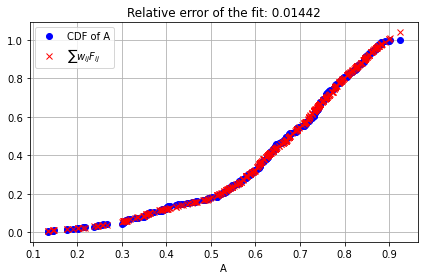

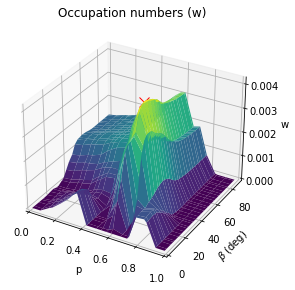

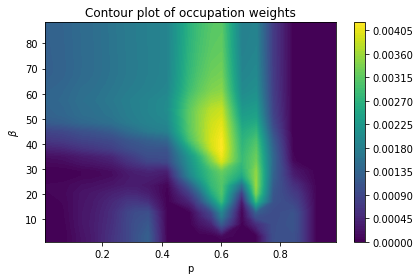

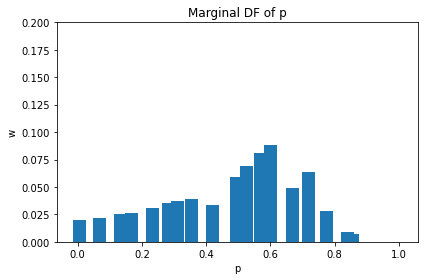

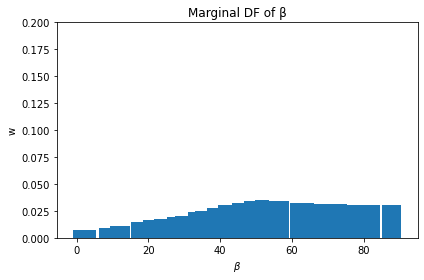

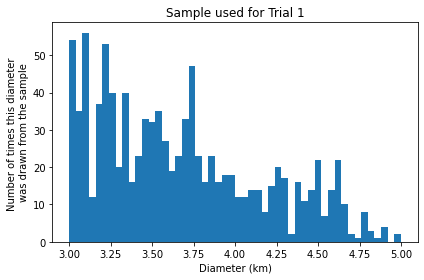

Smoothing the solution...


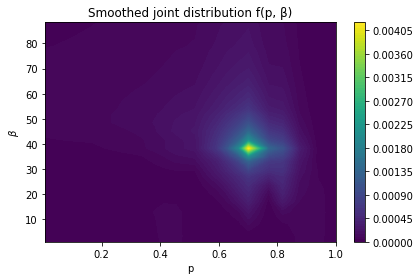

Trial 2 of 100


/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:172: RuntimeWarning: invalid value encountered in sqrt


Solving the weights w_ij for the bins (p_i, beta_j)...
Solution obtained!
The highest peak: P = 0.5202554536477851, BETA = 0.34345742397318796
Relative error: 0.022891547437935617


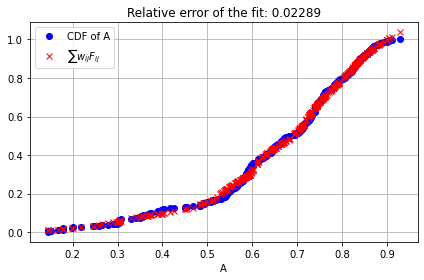

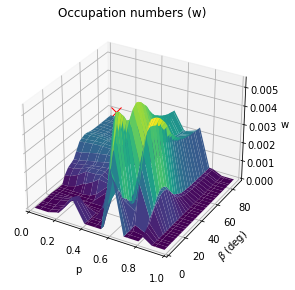

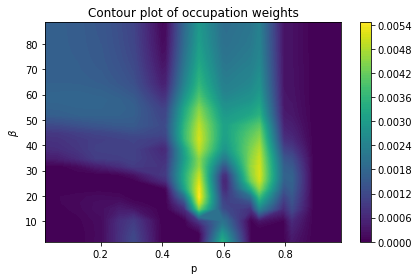

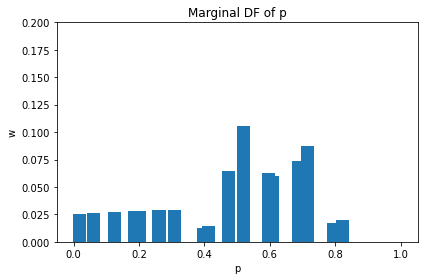

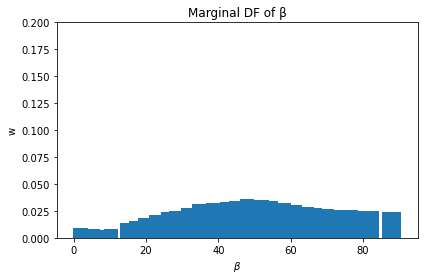

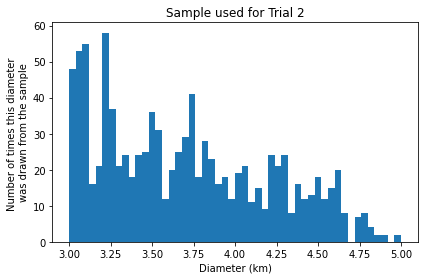

Smoothing the solution...


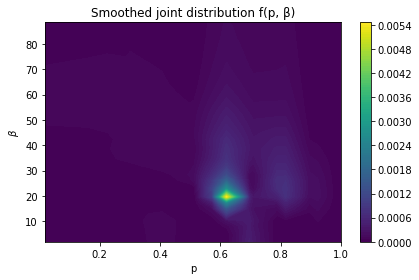

Trial 3 of 100


/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:172: RuntimeWarning: invalid value encountered in sqrt


Solving the weights w_ij for the bins (p_i, beta_j)...
Solution obtained!
The highest peak: P = 0.5411129753977594, BETA = 0.7681740090769497
Relative error: 0.012331868905779001


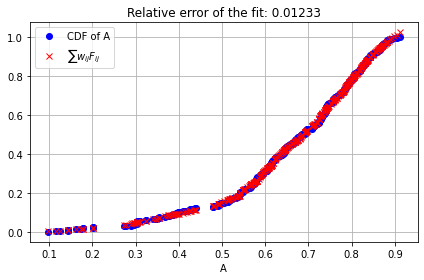

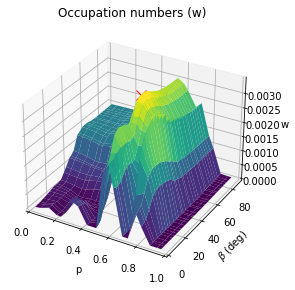

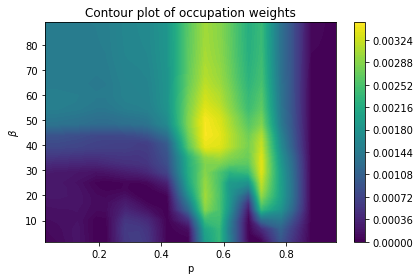

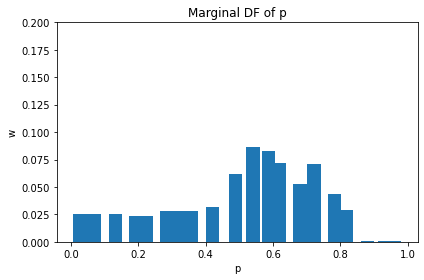

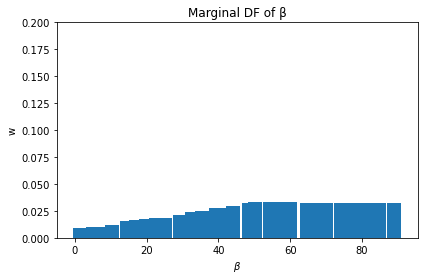

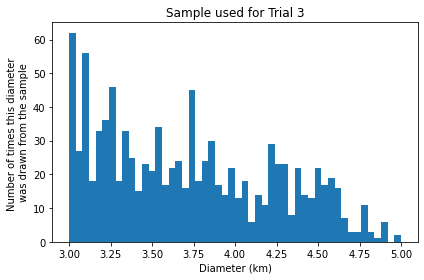

Smoothing the solution...


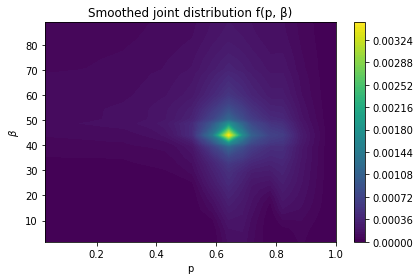

Trial 4 of 100


/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:172: RuntimeWarning: invalid value encountered in sqrt


Solving the weights w_ij for the bins (p_i, beta_j)...
Solution obtained!
The highest peak: P = 0.7149854596360481, BETA = 0.5296035024508627
Relative error: 0.017724682159407416


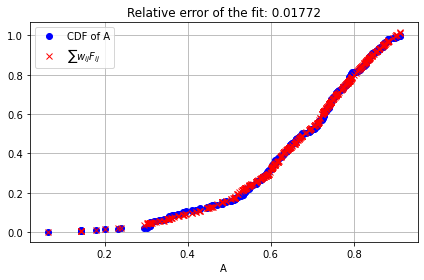

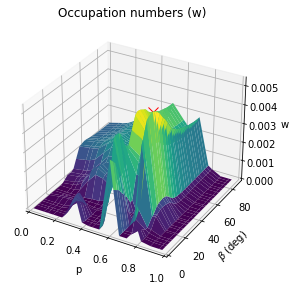

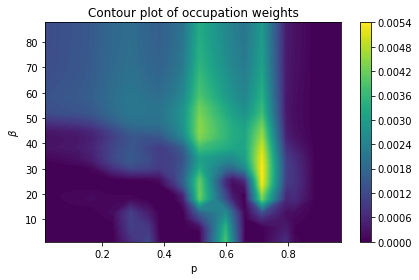

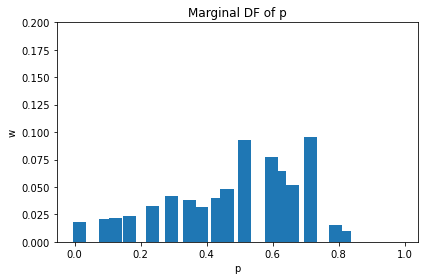

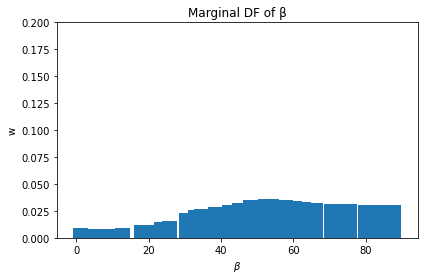

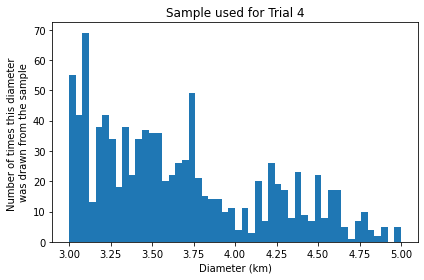

Smoothing the solution...


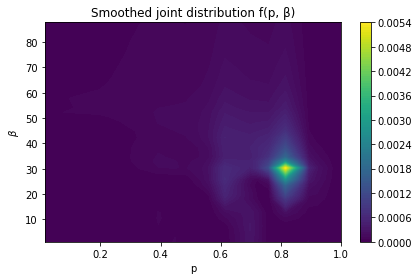

Trial 5 of 100


/usr/local/lib/python3.7/site-packages/ipykernel_launcher.py:172: RuntimeWarning: invalid value encountered in sqrt


KeyboardInterrupt: 

In [252]:
## MAIN PART OF THE CODE

datadir = '/Users/ssonnett/Desktop/work/MBA_SFDs/Fam'+famid+'_data_'+cat+'_'+filterpriority+'/'
outdir = '/Users/ssonnett/Desktop/work/MBA_SFDs/ForcedN'+str(wanted)+'_Fam'+famid+'_analysis_'+cat+'_'+filterpriority+'_'+str(diam_low)+'km_to_'+str(diam_high)+'km'
name_mpced_n_full = np.genfromtxt(neowise_fle,unpack=True,usecols=(2),delimiter=',',dtype=str)
name_mpced_n = np.asarray([name_mpced_n_full[i][1:-1].replace(' ','') for i in range(len(name_mpced_n_full))])
diam_n = np.genfromtxt(neowise_fle,unpack=True,usecols=(11),delimiter=',',dtype=float)

allfiles = []

for file in os.listdir(datadir):
    if file.endswith(".obs"):
        if file.startswith('Nofilter'):
            continue
        else:
            allfiles.append(os.path.join(datadir, file))

lcg_files = np.asarray(allfiles)

lcg_files_diammatch = []
for i in range(len(lcg_files)):

    objname = lcg_files[i].split('/')[-1].split('.')[0]
    objname_mpec = convert_to_mpecname(objname)
    diammatch = np.mean(np.asarray(diam_n.compress((name_mpced_n == objname_mpec).flat),dtype=float))
    if diammatch >= diam_low and diammatch <= diam_high:
        lcg_files_diammatch.append(lcg_files[i])
        


try:
    os.mkdir(outdir)
except:
    shutil.rmtree(outdir)
    os.mkdir(outdir)
    
    

if overwrite is True:
    wfile = open(outdir+'/SummaryAnalysis_Famid'+famid+'.txt','w+')
    wfile.write('Trial  Pmax    Betamax    Relerr  N_obj  AvgPointsPerObj  N_apparitions_total\n')
    wfile.flush()
else:
    wfile = open(outdir+'/SummaryAnalysis_Famid'+famid+'.txt','a')
    
## Define the number of asteroids to randomly select from the input population, 
## for assessing the shape and pole properties
try:
    Ndraws
except NameError:
    Ndraws = None

if Ndraws is None or (isinstance(Ndraws, (list, np.ndarray)) and len(Ndraws) == 0):
    Ndraws = 1000

    
    
for trial in range(Ntrials):

    print('Trial '+str(trial+1)+' of '+str(Ntrials))
    
    if overwrite is True:
        try:
            os.mkdir(outdir+'/Trial'+str(trial+1))
        except:
            shutil.rmtree(outdir+'/Trial'+str(trial+1))
            os.mkdir(outdir+'/Trial'+str(trial+1))
    else:
        try:
            os.mkdir(outdir+'/Trial'+str(trial+1))
        except:
            continue
    
    # Initialize variables
    A_tot = []
    Npoints_avg = []
    marginplots = True
    Napparlist = np.zeros((Ndraws, 1))
    Objects_drawn = []
    
    objfile = open(outdir+'/Trial'+str(trial+1)+'/ObjectsDrawn_famid'+str(famid)+'trial'+str(trial+1)+'.txt','w+')
    objfile.write('Filepath   Diameter \n')
    objfile.flush()
    
    for draw in range(Ndraws):

        ## select an object with an average NEOWISE-catalogued diameter within the bounds set

        fname = random.choice(lcg_files_diammatch)
        objname = fname.split('/')[-1].split('.')[0]
        objname_mpec = convert_to_mpecname(objname)
        diammatch = np.mean(np.asarray(diam_n.compress((name_mpced_n == objname_mpec).flat),dtype=float))
                        
        
        Nppo,Nappar,A = lcg_read_WISE(fname)
        if wanted <= len(np.asarray(A)):
            isample = list(np.arange(len(A)))
            iselect = random.sample(isample,wanted)    
            Npoints_avg = np.mean(Npoints[iselect])
            Nappar = Nappar[iselect]
            A = A[iselect]

        # Keep information on the number of apparitions
        Napparlist[draw] = Nappar
        Npoints_avg.append(Nppo)

        # Add to the list of amplitudes 
        A_tot += list(A)
        
        Objects_drawn.append(fname.split('/')[-1].split('.')[0])
        objfile.write(fname.split('.')[0]+'  '+str(int(Nppo))+'  '+str(round(diammatch,2))+str('\n'))
        objfile.flush()
    
    objfile.close()
    
    A_tot = np.asarray(A_tot)
    Npoints_avg = np.asarray(Npoints_avg)
    Asort = np.sort(A_tot)
    CDFA = np.linspace(1 / len(Asort), 1, len(Asort))

    pmax,betamax,relerr,M,W_back,W,P,BETA,P_Gr,BETA_Gr = leader_invert(Asort)
    
    Nobjs = len(np.asarray(list(set(Objects_drawn))))
    
    wfile.write("%s  %1.5f  %2.5f  %1.4f  %5i  %3i  %5i\n" % (trial+1,pmax,(betamax*(180./np.pi)),relerr,Nobjs,np.median(Npoints_avg),np.sum(Napparlist)))
    wfile.flush()

    if convert2degrees is True:
        BETA = np.rad2deg(BETA)
        BETA_Gr = np.rad2deg(BETA_Gr)
        betamax = np.rad2deg(betamax)
    
    leader_plots()

    leader_postprocess_WISE()


wfile.close()

trials,pmax_all,betamax_all,relerr_all = np.genfromtxt(outdir+'/SummaryAnalysis_Famid'+famid+'.txt',unpack=True,dtype=float,usecols=(0,1,2,3))

plot_alltrials(betamax_all,'Peak of '+r'$\beta$'+' distribution','Summary_betamax_Famid'+famid)
plot_alltrials(pmax_all,'Peak of p distribution','Summary_pmax_Famid'+famid)
